# Univariate Analysis

## Imports and Data Loading


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv("../data/processed/processed_telco_customer_churn.csv")

In [42]:
categorical_cols = df.select_dtypes(include=["object", 'str']).columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:\n", categorical_cols)


print("\nNumerical columns:\n", numerical_cols)

Categorical columns:
 ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Numerical columns:
 ['tenure', 'MonthlyCharges', 'TotalCharges']


## Descriptive Statistics For Numerical Variables

In [43]:
def descriptive_statistics_numerical(df, numerical_cols) -> pd.DataFrame:

    """ Calculates descriptive statistics for numerical columns of a DataFrame, including summary statistics like:
    - Count, Mean, Median
    - Standard Deviation
    - Coefficient of Variation
    - Minimum and Maximum
    - Quartiles (Q1, Q3) and Interquartile Range (IQR)
    - Skewness and Kurtosis
    """

    stats = []

    for col in numerical_cols:

        col_stats = {
            "Feature": col,
            "Count": df[col].count(),
            "Mean": df[col].mean(),
            "Median": df[col].median(),
            "Std Dev": df[col].std(),
            "CV": df[col].std() / df[col].mean() if df[col].mean() != 0 else np.nan,
            "Min": df[col].min(),
            "Q1": df[col].quantile(0.25),
            "Q3": df[col].quantile(0.75),
            "IQR": df[col].quantile(0.75) - df[col].quantile(0.25),
            "Max": df[col].max(),
            "Skewness": df[col].skew(),
            "Kurtosis": df[col].kurt()
        }
    
        stats.append(col_stats)

    return pd.DataFrame(stats)

In [44]:
descriptive_stats_numerical = descriptive_statistics_numerical(df, numerical_cols)
descriptive_stats_numerical

,Feature,Count,Mean,Median,Std Dev,CV,Min,Q1,Q3,IQR,Max,Skewness,Kurtosis
0,tenure,4543,32.546555,29.000,24.505519,0.752937,0.00,9.00,56.0000,47.0000,72.0,0.231347,-1.387988
1,MonthlyCharges,5543,64.876403,70.550,30.101331,0.463980,18.25,35.75,89.9250,54.1750,118.6,-0.227777,-1.262225
2,TotalCharges,7032,2283.300441,1397.475,2266.771362,0.992761,18.80,401.45,3794.7375,3393.2875,8684.8,0.961642,-0.231799


### Quality Table

In [45]:
def get_numerical_quality_table(report):
    
    """
    This function receives a report DataFrame and returns a table with the quality of every numerical feature based on the following criteria:
    - Coefficient of Variation (CV) >= 0.7 indicates high variability relative to the mean
    - | Skewness | > 1  indicates a highly skewed distribution 
    - | Skewness | >= 0.5 indicates a moderately skewed distribution
    - Kurtosis >= 3 indicates heavy tails
    - Kurtosis high extreme values (e.g., > 10) indicate the presence of strong outliers
    """

    quality_table = []

    for _ , row in report.iterrows():

        quality_list = []

        feature = row['Feature']
        cv = pd.to_numeric(row['CV'], errors='coerce')
        skewness = pd.to_numeric(row['Skewness'], errors='coerce')
        kurtosis = pd.to_numeric(row['Kurtosis'], errors='coerce')

        if cv >= 0.7:
            quality_list.append('High Variability')
        
        if abs(skewness) > 1:
            quality_list.append('Highly Skewed')
        elif abs(skewness) >= 0.5:
            quality_list.append('Moderately Skewed')

        if kurtosis >= 3 and kurtosis <= 10:
            quality_list.append('Heavy Tails')
        elif kurtosis > 10:
            quality_list.append('Extreme Outliers')

        quality_table.append({
            "Feature": feature,
            "Challenges": ', '.join(quality_list) if quality_list else 'Statistically well-behaved'
        })

    return pd.DataFrame(quality_table)

In [46]:
get_numerical_quality_table(descriptive_stats_numerical)

,Feature,Challenges
0,tenure,High Variability
1,MonthlyCharges,Statistically well-behaved
2,TotalCharges,"High Variability, Moderately Skewed"


### Plots of Distributions

In [47]:
def plot_numerical_distributions(df, numerical_cols):
    
    """
    This function creates histograms and boxplots for each numerical feature in the DataFrame 
        to visualize their distributions and identify potential outliers.

    Small multiples of histograms and boxplots are generated for each numerical column, 
    allowing for a quick visual assessment of the distribution shape, central tendency, variability, 
    and presence of outliers in the data.
    """

    num_features = len(numerical_cols)
    fig, axes = plt.subplots(2, num_features, figsize=(4 * num_features, 6))

    for i, col in enumerate(numerical_cols):
        sns.histplot(df[col], kde=True, ax=axes[0, i])
        axes[0, i].set_title(f'Histogram of {col}')
        axes[0, i].set_xlabel(col)
        axes[0, i].set_ylabel('Frequency')

        sns.boxplot(x=df[col], ax=axes[1, i])
        axes[1, i].set_title(f'Boxplot of {col}')
        axes[1, i].set_xlabel(col)

    plt.tight_layout()
    plt.show()

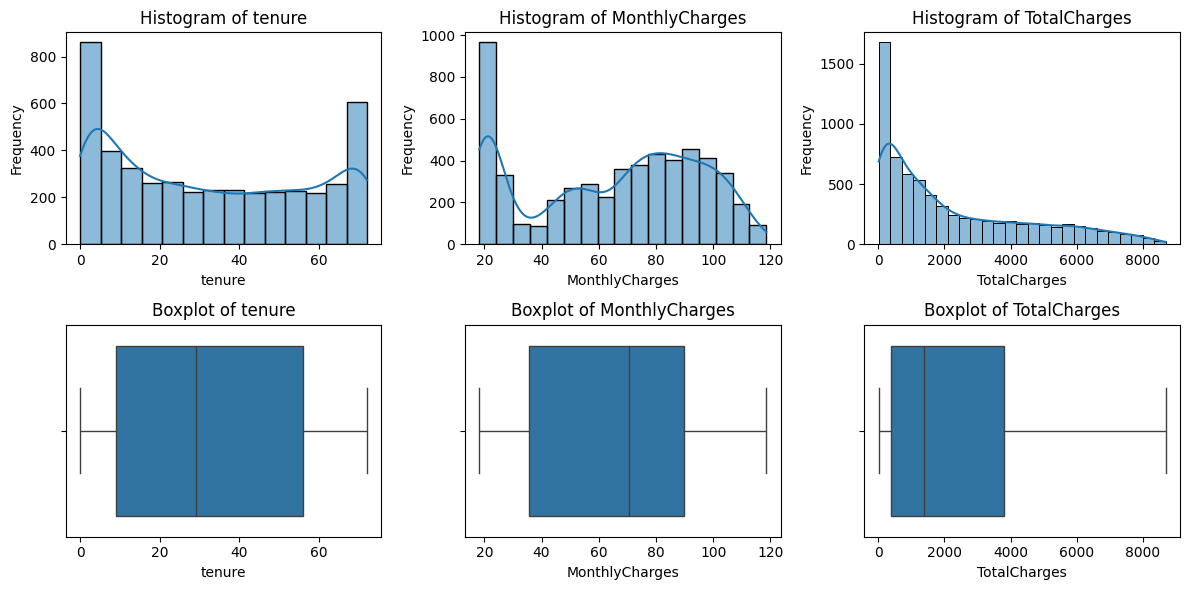

In [48]:
plot_numerical_distributions(df, numerical_cols)

## Descriptive Statistics for Categorical Variables

In [49]:
def descriptive_statistics_categorical(df, categorical_cols) -> pd.DataFrame:

    """ Calculates descriptive statistics for categorical columns of a DataFrame, including:
    - Absolute and relative frequency of each category
    - Cardinality (number of unique categories)
    - Cardinality Level (Low, Medium, High) 
    - Biggest category and its percentage
    - Number of rare levels (categories with less than 5% of the total frequency)
    - Missing % 
    """

    stats = []

    for col in categorical_cols:

        col_stats = {
            "Feature": col,
            "Cardinality": df[col].nunique(),
            "Cardinality Level": 'Low' if df[col].nunique() < 10 else 'Medium' if df[col].nunique() < 20 else 'High',
            "Biggest Category": df[col].value_counts().idxmax(),
            "% of Biggest Category": '{:.2f} %'.format(df[col].value_counts(normalize=True).max() * 100),
            "Num Rare Levels": (df[col].value_counts(normalize=True) < 0.05).sum(),
            "Missing %": '{:.2f} %'.format(df[col].isnull().mean() * 100)
        }
    
        stats.append(col_stats)

    return pd.DataFrame(stats)

In [50]:
descriptive_stats_categorical = descriptive_statistics_categorical(df, categorical_cols)
descriptive_stats_categorical

,Feature,Cardinality,Cardinality Level,Biggest Category,% of Biggest Category,Num Rare Levels,Missing %
0,gender,2,Low,Male,50.88 %,0,10.65 %
1,SeniorCitizen,2,Low,No,83.79 %,0,0.00 %
2,Partner,2,Low,No,51.55 %,0,14.20 %
3,Dependents,2,Low,No,70.04 %,0,0.00 %
4,PhoneService,2,Low,Yes,90.32 %,0,0.00 %
5,MultipleLines,3,Low,No,48.13 %,0,0.00 %
6,InternetService,3,Low,Fiber optic,44.02 %,0,14.20 %
7,OnlineSecurity,3,Low,No,49.67 %,0,0.00 %
8,OnlineBackup,3,Low,No,43.84 %,0,0.00 %
9,DeviceProtection,3,Low,No,43.94 %,0,0.00 %


## Load Descriptive Stats Into Files

In [51]:
descriptive_stats_numerical.to_markdown('../reports/descriptive_stats_numerical.md', index=False)
descriptive_stats_categorical.to_markdown('../reports/descriptive_stats_categorical.md', index=False)